# 02 — Signal Analysis

Studying the electrical characteristics of each appliance in detail.

**This notebook:**
- Computes steady-state power distributions per appliance
- Analyzes ON/OFF transition sharpness
- Studies periodic behavior (e.g. compressor cycling)
- Plots power histograms per appliance

**Why this matters:** Before building a classifier, I wanted to understand what makes appliance signals different from one another. Studying these electrical characteristics helps explain why certain features are useful and why some appliances are easier to identify than others.

### Appliance Mapping

According to the REFIT metadata for House 1:

- Appliance1 → Fridge
- Appliance2 → Freezer
- Appliance3 → Washer Dryer
- Appliance4 → Washing Machine
- Appliance5 → Toaster
- Appliance6 → Computer
- Appliance7 → Television
- Appliance8 → Microwave

This mapping will be used throughout the signal analysis to relate electrical patterns to real household devices.

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import medfilt
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
df = pd.read_csv('../data/processed/house1_7days.csv', index_col=0, parse_dates=True)
print(df.shape)
df.head(3)

(604800, 9)


,mains,Appliance1,Appliance2,Appliance3,Appliance4,Appliance5,Appliance6,Appliance7,Appliance8
Time,,,,,,,,,
2013-10-09 13:06:17,523.0,74.0,0.0,69.0,0.0,0.0,0.0,0.0,0.0
2013-10-09 13:06:18,523.0,74.0,0.0,69.0,0.0,0.0,0.0,0.0,0.0
2013-10-09 13:06:19,523.0,74.0,0.0,69.0,0.0,0.0,0.0,0.0,0.0


## Steady-state power distributions

For each appliance, when it is ON, what range of power does it draw?

Resistive loads (heaters, incandescent bulbs) are narrow and stable.
Motor loads (fridge, washer) are wider because the motor load varies.

These differences create distinctive electrical fingerprints that can be used for appliance identification.

In [3]:
appliance_map = {
    'Appliance1': 'Fridge',
    'Appliance2': 'Freezer',
    'Appliance3': 'Washer Dryer',
    'Appliance4': 'Washing Machine',
    'Appliance5': 'Toaster',
    'Appliance6': 'Computer',
    'Appliance7': 'Television',
    'Appliance8': 'Microwave'
}

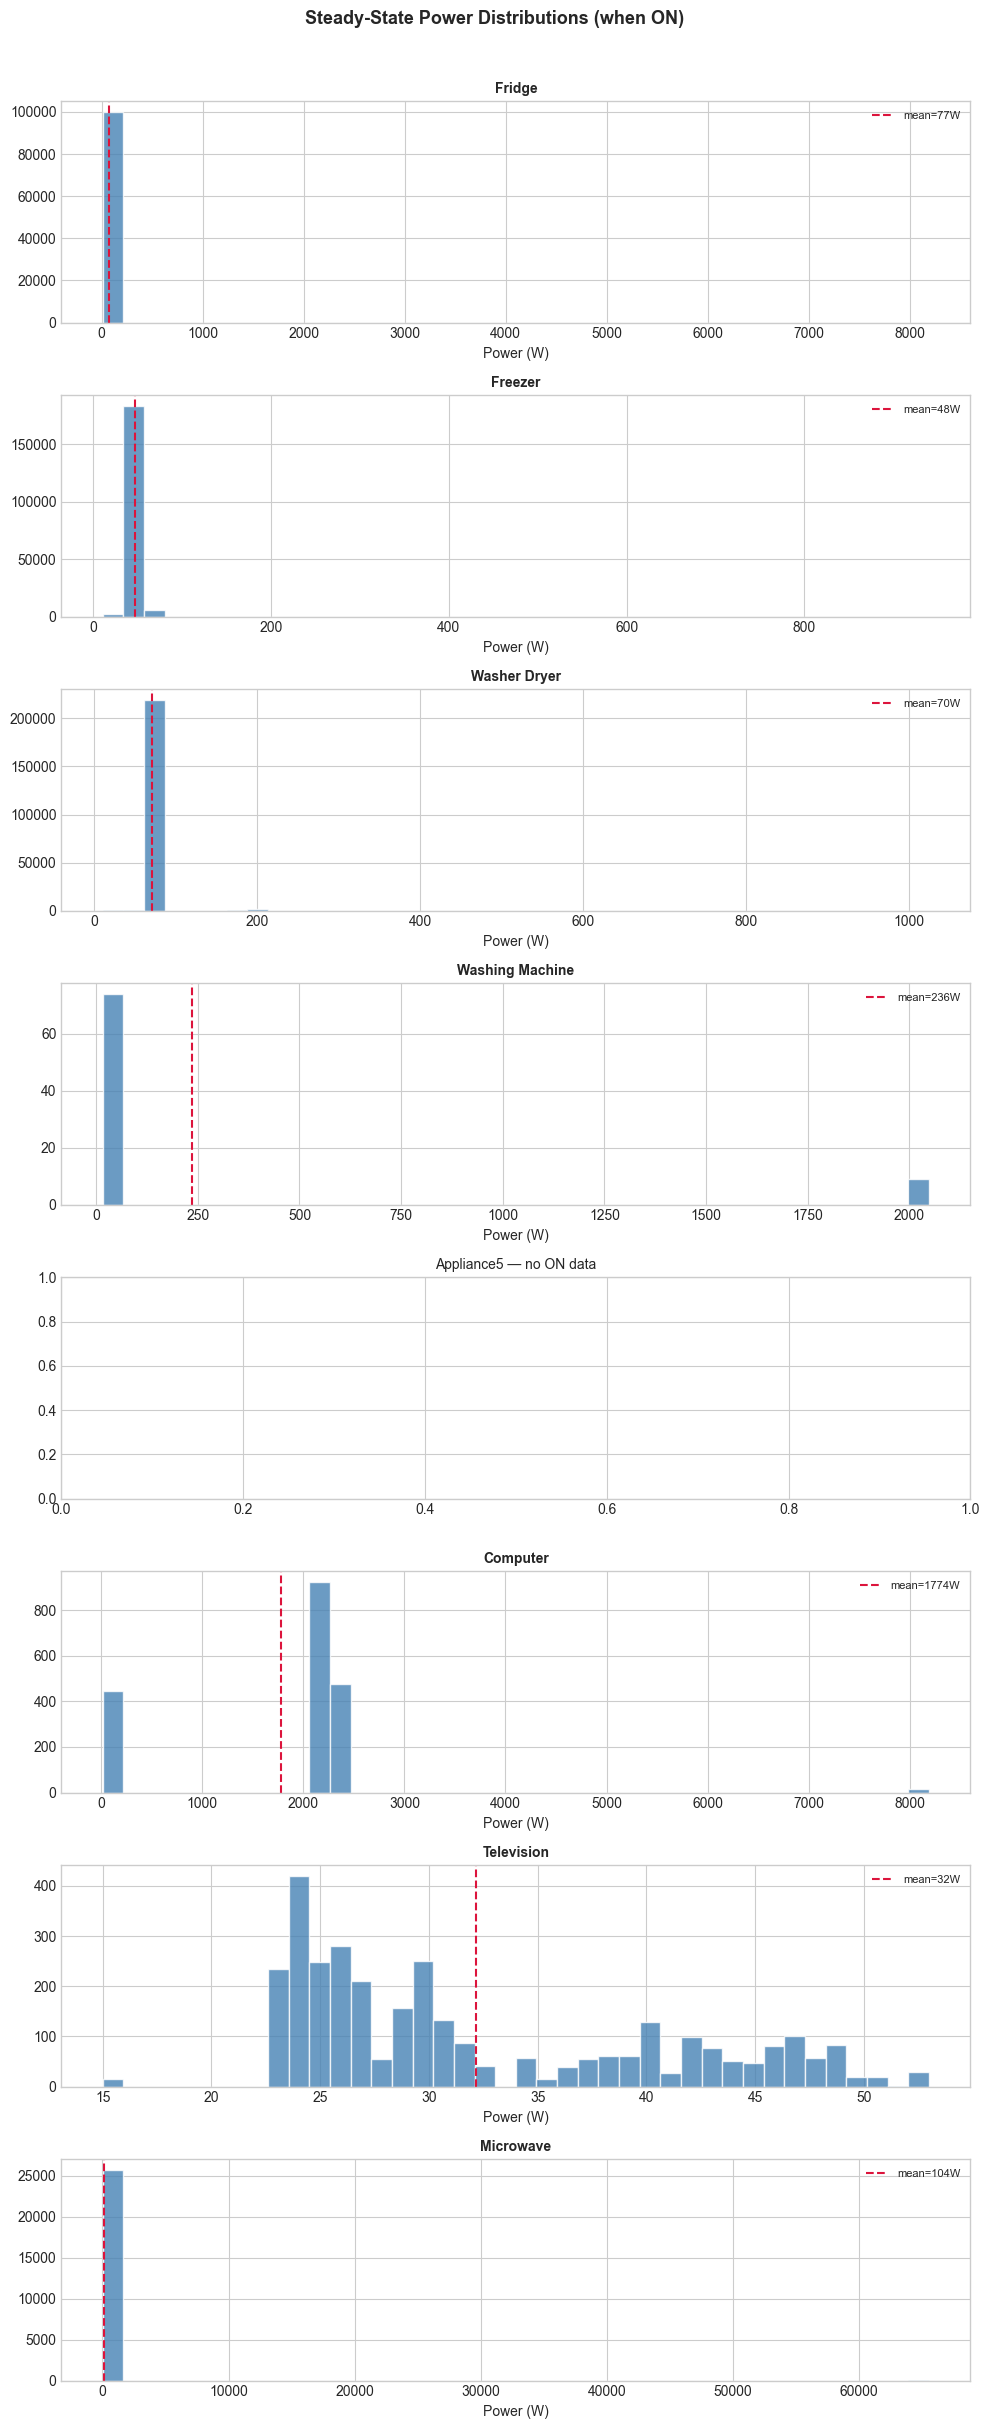

In [4]:
appliance_cols = [c for c in df.columns if c != 'mains']

fig, axes = plt.subplots(len(appliance_cols), 1, figsize=(10, 3*len(appliance_cols)))
if len(appliance_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, appliance_cols):
    # only plot when appliance is ON (power > 10W)
    on_data = df[col][df[col] > 10]
    if len(on_data) == 0:
        ax.set_title(f'{col} — no ON data', fontsize=10)
        continue
    ax.hist(on_data.values, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
    ax.axvline(on_data.mean(), color='crimson', linestyle='--', linewidth=1.5,
               label=f'mean={on_data.mean():.0f}W')
    display_name = appliance_map.get(col, col)
    ax.set_title(display_name, fontsize=10, fontweight='bold')
    ax.set_xlabel('Power (W)')
    ax.legend(fontsize=8)

plt.suptitle('Steady-State Power Distributions (when ON)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../outputs/02_power_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## My Observations

The refrigerator and freezer show relatively narrow power distributions, which is expected for compressor-based appliances operating around a typical steady-state level. In contrast, the washing machine and washer dryer exhibit greater variability, reflecting their multiple operating stages.

I also noticed that the microwave contains a few unusually large power values that may represent measurement noise or rare operating conditions. These observations suggest that steady-state power is useful but may not be sufficient on its own for reliable appliance identification.

## ON duration analysis

How long does each appliance stay ON per activation?

Microwave: typically 1–5 minutes.
Fridge: 10–25 minutes per compressor cycle.
Washer: 45–90 minutes per wash cycle.

Duration is a strong discriminating feature.

In [5]:
def get_on_durations(series, threshold=10, min_duration_s=5):
    '''
    Extract durations (in seconds) of each ON event for a given appliance.
    An ON event = consecutive samples above threshold.
    '''
    is_on = (series > threshold).astype(int)
    changes = is_on.diff().fillna(0)

    durations = []
    start = None

    for ts, val in changes.items():
        if val == 1:   # turned ON
            start = ts
        elif val == -1 and start is not None:  # turned OFF
            dur = (ts - start).seconds
            if dur >= min_duration_s:
                durations.append(dur)
            start = None

    return durations

# compute for each appliance
duration_data = {}
for col in appliance_cols:
    durs = get_on_durations(df[col])
    if len(durs) > 3:
        duration_data[col] = durs
        name = appliance_map.get(col, col)
        print(f'{name}: {len(durs)} events, median duration = {np.median(durs):.0f}s')

Fridge: 87 events, median duration = 1604s
Freezer: 174 events, median duration = 1096s
Washer Dryer: 114 events, median duration = 1933s
Computer: 6 events, median duration = 152s
Microwave: 8 events, median duration = 3256s


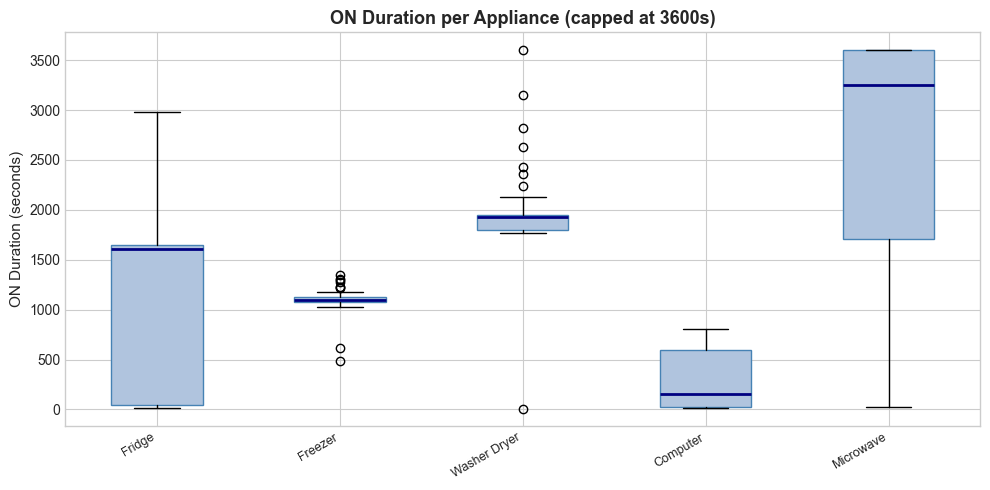

In [6]:
if duration_data:
    fig, ax = plt.subplots(figsize=(10, 5))
    labels_list = [appliance_map.get(k, k) for k in duration_data.keys()]
    data_list = [np.clip(duration_data[k], 0, 3600) for k in duration_data.keys()]  # cap at 1hr

    bp = ax.boxplot(data_list, patch_artist=True, vert=True,
                    boxprops=dict(facecolor='lightsteelblue', color='steelblue'),
                    medianprops=dict(color='navy', linewidth=2))
    ax.set_xticklabels(labels_list, rotation=30, ha='right', fontsize=9)
    ax.set_ylabel('ON Duration (seconds)', fontsize=11)
    ax.set_title('ON Duration per Appliance (capped at 3600s)', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('../outputs/02_on_durations.png', dpi=150)
    plt.show()

## My Observations

The ON-duration distributions vary significantly across appliances. The computer tends to operate in short bursts, while appliances such as the refrigerator, freezer, and washer dryer remain active for much longer periods.

I observed that duration is often more consistent for certain appliances than power consumption alone. This suggests that event duration could be a valuable feature for distinguishing appliances that operate at similar power levels.

## Compressor cycling — fridge behavior

The refrigerator compressor cycles on and off repeatedly throughout the day.
This creates a distinctive periodic pattern — very different from a light switch.

Plotting 6 hours of fridge data to see the cycle:

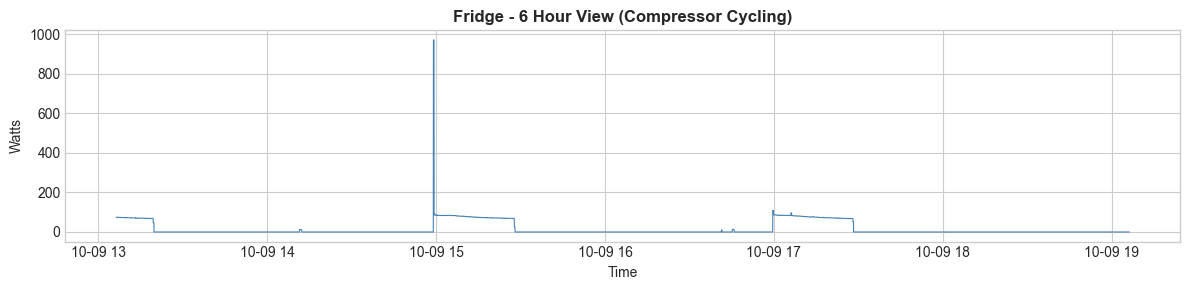

In [7]:
fridge_col = 'Appliance1'

fridge_6h = df[fridge_col].iloc[:6*3600]

fig, ax = plt.subplots(figsize=(12,3))
ax.plot(fridge_6h.index,
        fridge_6h.values,
        color='steelblue',
        linewidth=0.8)

ax.set_title('Fridge - 6 Hour View (Compressor Cycling)',
             fontsize=12,
             fontweight='bold')

ax.set_ylabel('Watts')
ax.set_xlabel('Time')

plt.tight_layout()
plt.savefig('../outputs/02_fridge_cycling.png', dpi=150)
plt.show()

## My Observations

The refrigerator exhibits clear compressor cycling behavior. Power consumption alternates between a low OFF state and a relatively stable ON state around 70–90 W.

I also observed a brief high-power spike during one activation, which may correspond to compressor startup behavior. This periodic pattern provides a strong appliance fingerprint that differs significantly from devices such as microwaves or computers.

## Key Takeaways

From the signal analysis performed so far, several useful appliance characteristics emerge:

- Steady-state power varies significantly across appliances.
- Some appliances operate within a narrow power range, while others show multiple operating states.
- ON durations differ substantially between appliances.
- Certain appliances exhibit highly consistent behavior, whereas others display large variability.

These characteristics will later be converted into numerical features for machine learning models.

## Summary: Key signal characteristics per load type

| Load Type | Steady-State Power | Transition | Duration | Periodicity |
|---|---|---|---|---|
| Refrigerator | 100–200W | Gradual (motor) | 10–25 min | Yes (compressor) |
| Microwave | 1000–1500W | Instant | 1–5 min | No |
| Washer/Dryer | 400–5000W | Gradual | 45–90 min | No |
| Lighting | 60–300W | Instant | Variable | No |
| Dishwasher | 1200–1500W | Gradual | 60–90 min | No |


The signal analysis revealed clear differences in appliance behavior. Refrigeration loads exhibited periodic cycling patterns, while appliances such as the washer dryer and washing machine showed greater variability in power consumption and operating duration.

These observations suggest that features such as steady-state power, event duration, and periodicity can help distinguish appliances and will be used in later stages of the NILM pipeline.